# DBGSOM Paper Benchmarks

Reproducible results for the JOSS paper. Run the scripts first:

```bash
uv run python paper_benchmarks/clustering.py
uv run python paper_benchmarks/scaling.py
```


In [36]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS = Path("results")

## Clustering — Digits dataset


In [37]:
df_cluster = pd.read_csv(RESULTS / "clustering_digits.csv", index_col="Algorithm").T
df_cluster

Algorithm,DBGSOM,MiniSom,SuSi,torchsom
n_prototypes,144.0000,144.0000,144.0000,144.0000
Time (s),1.0950,4.2610,0.1710,0.8330
QE,4.7178,4.7523,5.6633,6.1444
TE,0.0299,0.1694,0.0889,0.1500
ARI,0.1350,0.1370,0.2100,0.4690
Silhouette,-0.0270,-0.0020,-0.1040,-0.0200


## Scaling — training time vs. N


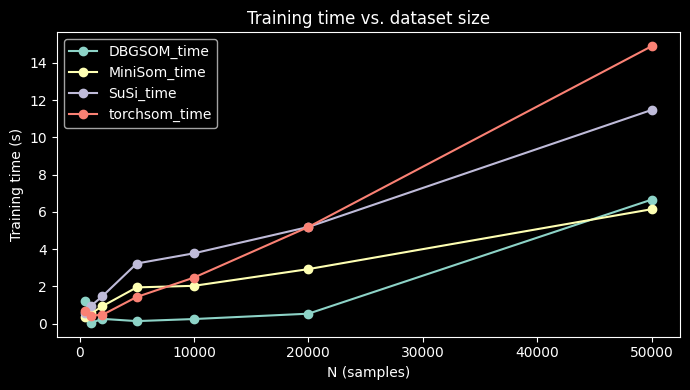

,DBGSOM_time,DBGSOM_n_nodes,DBGSOM_qe,DBGSOM_te,MiniSom_time,MiniSom_n_nodes,MiniSom_qe,SuSi_time,SuSi_n_nodes,SuSi_qe,torchsom_time,torchsom_n_nodes,torchsom_qe
N,,,,,,,,,,,,,
500,1.224,17,0.9945,0.3980,0.325,25,1.0275,0.540,25,2.5598,0.648,25,2.1124
1000,0.035,28,0.9946,0.0000,0.543,36,1.0014,0.946,36,1.8332,0.430,36,2.1052
2000,0.251,46,1.0006,0.0795,0.933,49,1.0012,1.467,49,1.2066,0.466,49,2.3707
5000,0.131,87,0.9408,0.2376,1.942,100,0.9679,3.225,100,0.9955,1.427,100,2.0232
10000,0.242,94,0.9384,0.2885,2.026,100,0.9737,3.773,100,0.9966,2.469,100,1.9543
20000,0.529,122,0.9329,0.2365,2.924,144,0.9666,5.188,144,0.9800,5.186,144,1.9888
50000,6.657,210,0.9284,0.1303,6.142,225,0.9667,11.474,225,0.9600,14.900,225,1.8681


In [38]:
df_scale = pd.read_csv(RESULTS / "scaling.csv", index_col="N")
times = ["DBGSOM_time", "MiniSom_time", "SuSi_time", "torchsom_time"]

fig, ax = plt.subplots(figsize=(7, 4))
for col in df_scale[times]:
    ax.plot(df_scale.index, df_scale[col], marker="o", label=col)

ax.set_xlabel("N (samples)")
ax.set_ylabel("Training time (s)")
ax.set_title("Training time vs. dataset size")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "scaling_plot.png", dpi=150)
plt.show()
df_scale

In [39]:
x = (50000 / 200) ** (30 / 31) * 3 / 2
x

313.8183713812973

In [40]:
5 * 50000**0.5

1118.033988749895